# NaI(Tl) Pulse Modeling

In this notebook we modeling the NaI(Tl) detector response pulse based on this papers

- A new pulse model for NaI(Tl) detection systems (Wuyun Xiao, Abi T. Farsoni, Haori Yang, David H. Hamby) http://dx.doi.org/10.1016/j.nima.2014.06.022

- Model-based pulse deconvolution method for NaI(Tl) detectors (Wuyun Xiao, Abi T. Farsoni, Haori Yang, David M. Hamby) http://dx.doi.org/10.1016/j.nima.2014.09.034

## NaI(Tl) Detector Pulse Model

To describe the temporal structure of the pulses produced by a PMT-coupled NaI(Tl) scintillation detector, the pulse formation process is modeled as a sequence of three physical stages. Following the model presented by Wuyun Xiao, Abi T. Farsoni, et al., the total detector response is represented as the convolution of the individual responses of these stages:

$$
R(t)=R_1(t)\otimes R_2(t)\otimes R_3(t)
$$

where $\otimes$ denotes the convolution operator.

### 1. Radiation–scintillator interaction

The first stage represents the interaction between the incident ionizing radiation and the inorganic scintillator. This interaction generates free electrons, holes, and excitons, which propagate through the crystal until they reach and excite activator centers.

Because this stage involves a large number of low-probability and approximately independent processes, its temporal response can be approximated by a Gaussian function:

$$
R_1(t)=A\,U(t)
\exp\left(-\frac{t^2}{2\sigma_1^2}\right)
$$

where $A$ is an amplitude factor, $\sigma_1$ is the standard deviation, and $U(t)$ is the unit-step function.

In the implementation, this contribution is represented by the `GaussianResponse` class.

The Gaussian component also incorporates the Gaussian contribution associated with the PMT response. Since the convolution of two Gaussian functions is another Gaussian function, their combined standard deviation is

$$
\sigma=\sqrt{\sigma_1^2+\sigma_2^2}.
$$

Therefore, the model uses the resulting $\sigma$ directly:

$$
G(t)=U(t)
\exp\left(-\frac{t^2}{2\sigma^2}\right).
$$


### 2. Scintillator light emission

In the second stage, the excited activator centers undergo de-excitation and emit scintillation light through fluorescence.

The temporal response is modeled as a sum of exponential components:

$$
R_2(t)
=
B\,U(t)
\sum_{i=1}^{M}
\eta_i
\exp\left(-\frac{t}{\tau_i}\right)
$$

where:

- $\eta_i$ are the weighting factors of the individual scintillation components,
- $\tau_i$ are their corresponding decay-time constants,
- $B$ is an amplitude factor.

The weighting factors satisfy

$$
\sum_{i=1}^{M}\eta_i=1.
$$

For the NaI(Tl) model used here, two scintillation components are considered. The `LightEmission` class implements this response as the sum of the exponential components.

The Heaviside function $U(t)$ ensures causality, so that the response is zero for $t<0$.


### 3. Photomultiplier tube response

The third stage represents the temporal response of the photomultiplier tube (PMT).

The PMT response is more complex than a single exponential. Following the model, it is represented by the convolution of a Gaussian contribution and a sum of exponential components:

$$
R_3(t)
=
C\,U(t)
\exp\left(-\frac{t^2}{2\sigma_2^2}\right)
\otimes
\left[
\sum_{j=1}^{N}
\kappa_j
\exp\left(-\frac{t}{\lambda_j}\right)
\right].
$$

Here, $\kappa_j$ are the weighting factors and $\lambda_j$ are the corresponding decay-time constants of the PMT exponential components. The weighting factors satisfy

$$
\sum_{j=1}^{N}\kappa_j=1.
$$

In the implementation, the Gaussian contribution of the PMT is combined with the Gaussian contribution from the first stage through the resulting parameter $\sigma$. Therefore, the `PMTExp` class implements only the exponential part of the PMT response.


### 4. Complete detector response

The three physical stages occur sequentially. Therefore, the total detector response is obtained by convolving their individual responses:

$$
R(t)
=
R_1(t)
\otimes
R_2(t)
\otimes
R_3(t).
$$

Using the properties of linear time-invariant systems and the convolution of Gaussian functions, the model can be written as

$$
R(t)
=
H
\left[
U(t)
\exp\left(-\frac{t^2}{2\sigma^2}\right)
\right]
\otimes
\left[
U(t)
\sum_{i=1}^{M}
\eta_i
\exp\left(-\frac{t}{\tau_i}\right)
\right]
\otimes
\left[
U(t)
\sum_{j=1}^{N}
\kappa_j
\exp\left(-\frac{t}{\lambda_j}\right)
\right].
$$

The parameter $H$ is proportional to the energy deposited by the incident particle and determines the overall amplitude of the resulting pulse.

The implementation follows this structure using object-oriented programming. Each physical stage is represented by a class:

| Physical stage | Mathematical response | Python class |
|---|---|---|
| Radiation–crystal interaction | Gaussian | `GaussianResponse` |
| Scintillation light emission | Sum of exponentials | `LightEmission` |
| PMT exponential response | Sum of exponentials | `PMTExp` |
| Complete detector | Sequential convolution | `PulseDetector` |

The `PulseDetector` class uses **composition**: it contains one object for each physical stage and combines their responses through numerical convolution.

For a discrete time vector, the continuous convolution is approximated numerically using `fftconvolve`. The sampling interval

$$
\Delta t=t_{n+1}-t_n
$$

is included in each convolution to approximate the corresponding continuous-time integral.

Thus, the Python implementation preserves the physical structure of the convolutional model while organizing each stage as an independent and reusable object.

In [205]:
import numpy as np
from scipy.signal import fftconvolve
import matplotlib.pyplot as plt


#Define the contribution components of signal

class GaussianResponse:
    """
    This component of convolutional model represent the 
    gaussian contribution of radiation-crystal interaction and
    crystal activators excitation combined with gaussian component
    of PMT response, resulting in new gaussian with sigma = sqrt(sigma_1**2 + sigma_2**2)
    """
    def __init__(self, sigma):
        self.sigma =  sigma

    def response(self, t):
        return np.exp(
            -t ** 2 / (2 * self.sigma ** 2)
        )


class LightEmission:
    """
    This component represent the activation centers de-excitation
    and light (fluorescence) emission process 
    """
    def __init__(self, eta, tau):
        self.eta = eta
        self.tau = tau

    def response(self, t):

        u = np.heaviside(t, 0)

        #Sum broadcasting
        return np.sum(                                
            eta[:, None]
            * np.exp(-t[None, :] / tau[:, None])
            * u[None, :],   
            axis = 0
            )


class PMTExp:
    """
    Coupled photomultiplier response component (only exponential).
    Gaussian contribution its included in gaussian_response function
    """
    def __init__(self, kappa, lamb):
        self.kappa = kappa
        self.lamb = lamb

    def response(self, t):

        u = np.heaviside(t, 0)

        #Sum broadcasting
        return np.sum(
            kappa[:, None]
            * np.exp(-t[None, :] / lamb[:, None])
            * u[None, :],   
            axis = 0
            )


class PulseDetector:
    """
    Calculates the full time response R(t) of the detector by convolving 
    the physical stages of the signal forming process.
    
    H is a factor proportional to the energy deposition of the incident particle.
    """
    def __init__(self, gaussian, light, pmt):
        self.gaussian = gaussian
        self.light = light
        self.pmt = pmt

    def response(self, H, t):

        dt = t[1] - t[0]

        # Generate the individual response components
        R1 = self.gaussian.response(t)
        R2 = self.light.response(t)
        R3 = self.pmt.response(t)
    
        R12 = fftconvolve(
            R1, R2, mode='full'
            )[:len(t)] * dt

        R = H * fftconvolve(
            R12, R3, mode='full'
            )[:len(t)] * dt

        return R


In [206]:
#Fitted Params

# With sigma = sqrt(sigma_1**2 + sigma_2**2)[cite: 1]
sigma = 9.2448e-9  

# Scintillator light emission parameters[cite: 1]
eta = np.array([0.9901, 0.0099])
tau = np.array([227.27e-9, 2677.2e-9])

# PMT response parameters[cite: 1]
kappa = np.array([0.9278, 0.0722])
lamb = np.array([10.750e-9, 67.021e-9])

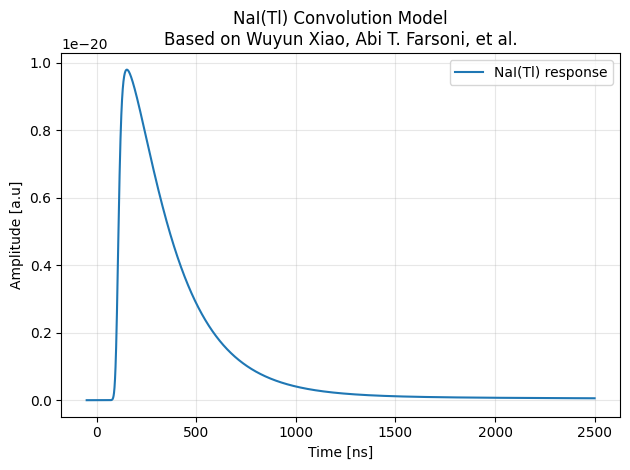

In [ ]:
NaI_Tl_model = PulseDetector(
    GaussianResponse(sigma),
    LightEmission(eta, tau),
    PMTExp(kappa, lamb)
)

#Fitted Amplitude
H = 4.105e-5
#time vector
t = np.linspace(-50e-9, 2500e-9, 5000)

NaI_Tl_pulse = NaI_Tl_model.response(H = H, t = t)

#Calcu


plt.plot(t*1e9, NaI_Tl_pulse, label="NaI(Tl) response")

plt.xlabel("Time [ns]")
plt.ylabel("Amplitude [a.u]")
plt.title(
    "NaI(Tl) Convolution Model\n"
    "Based on Wuyun Xiao, Abi T. Farsoni, et al."
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Decay Time of Light Emission tau")

_________

Johnson–Nyquist Noise

This noise component is additive and is implemented directly in hardware using an LFSR structure to generate the random variables required for the Irwin–Hall implementation. The equivalent process is shown here. However, this noise component is not added to the signal in the present model; instead, it is introduced in the subsequent hardware stage, after amplitude scaling.

Experimental mean      = 509.9877
Theoretical mean       = 512.0000

Experimental std. dev. = 147.8109
Theoretical std. dev.  = 147.8005


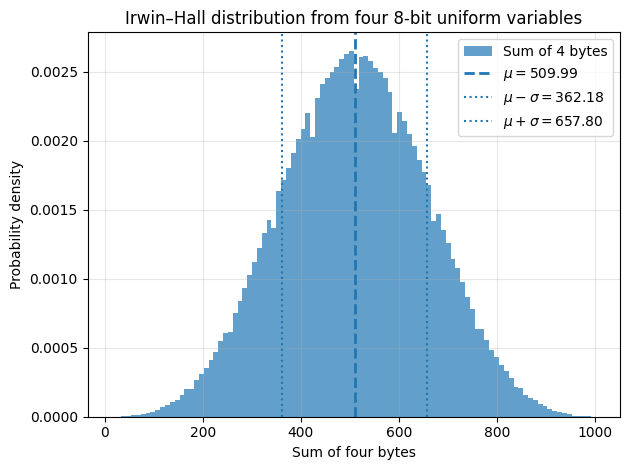

In [169]:
# Number of samples
N = 1_000_000

# Random generator
rng = np.random.default_rng()

# Generate 32-bit uniform random numbers
unif_data = rng.integers(
    0,
    2**32,
    size=N,
    endpoint=False,
    dtype=np.uint32
)

# Extract the four bytes
byte_1 = (unif_data >> 24) & 0xFF
byte_2 = (unif_data >> 16) & 0xFF
byte_3 = (unif_data >> 8) & 0xFF
byte_4 = unif_data & 0xFF

# Sum the four bytes
byte_sum = byte_1 + byte_2 + byte_3 + byte_4

# Experimental statistics
mu = np.mean(byte_sum)
sigma = np.std(byte_sum)

# Theoretical statistics
mu_theory = 4 * 2**8 / 2
sigma_theory = np.sqrt(4 * ((2**8)**2 - 1) / 12)

print(f"Experimental mean      = {mu:.4f}")
print(f"Theoretical mean       = {mu_theory:.4f}")
print()
print(f"Experimental std. dev. = {sigma:.4f}")
print(f"Theoretical std. dev.  = {sigma_theory:.4f}")

# Histogram
plt.hist(
    byte_sum,
    bins=100,
    density=True,
    alpha=0.7,
    label="Sum of 4 bytes"
)

# Experimental mean
plt.axvline(
    mu,
    linestyle="--",
    linewidth=2,
    label=fr"$\mu = {mu:.2f}$"
)

# Experimental ±1 sigma
plt.axvline(
    mu - sigma,
    linestyle=":",
    linewidth=1.5,
    label=fr"$\mu-\sigma = {mu-sigma:.2f}$"
)

plt.axvline(
    mu + sigma,
    linestyle=":",
    linewidth=1.5,
    label=fr"$\mu+\sigma = {mu+sigma:.2f}$"
)

plt.xlabel("Sum of four bytes")
plt.ylabel("Probability density")
plt.title("Irwin–Hall distribution from four 8-bit uniform variables")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()